In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid_cells.random_walk import generate_bat_flight
from grid_cells.bat_hd_system import BatHeadDirectionSystem
from grid_cells.plot_tools import angular_error, smooth_ts
import os
from concurrent.futures import ThreadPoolExecutor

DATA_DIR = "../simulation_data/hebb"
PLOTS_DIR = "../plots/hebb"
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

In [2]:
T = 400
dt = 0.5e-3
n = 256
intrinsic_noise = 0.005
input_noise = 0
n_conj = 20
n_anchor = 5
interval=100
bat_flight = generate_bat_flight(T=T, dt=dt)


net = BatHeadDirectionSystem(
    input_noise=input_noise,
    intrinsic_noise=intrinsic_noise,
    n_conjunctive=n_conj,
    gravity_input=True,
)
net_anchor = BatHeadDirectionSystem(
    input_noise=input_noise,
    intrinsic_noise=intrinsic_noise,
    n_conjunctive=n_conj,
    n_anchor=n_anchor,
    gravity_input=True,
)

net.warm_up(initial_dir=bat_flight["dir_torus"][0])
net_anchor.warm_up(initial_dir=bat_flight["dir_torus"][0])

n_steps = bat_flight["pos"].shape[0]

with ThreadPoolExecutor(max_workers=2) as executor:
    anchor_future = executor.submit(
        net_anchor.run_simulation,
        bat_flight["dir_vel"],
        dir=bat_flight["dir_sphere"],
        inverted=bat_flight["inverted"],
        save_weights=True,
        interval=interval
    )
    recording_future = executor.submit(
        net.run_simulation,
        bat_flight["dir_vel"],
        interval=interval
    )

    recording_anchor = anchor_future.result()
    recording = recording_future.result()

100%|██████████| 799999/799999 [00:48<00:00, 16621.31it/s]


Ran warm up for 140 steps
Ran warm up for 140 steps


Running Simulation Steps: 100%|██████████| 800000/800000 [05:28<00:00, 2436.49it/s]


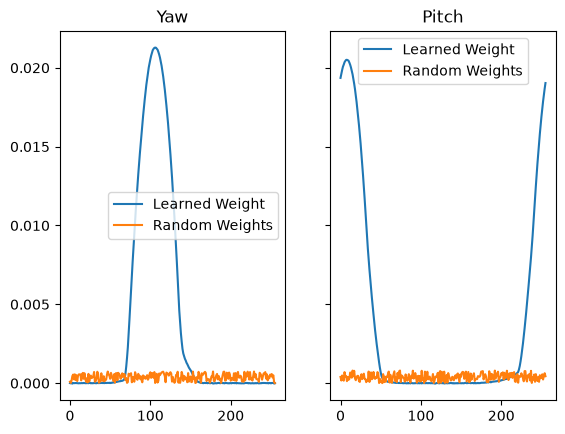

In [ ]:
fig, ax = plt.subplots(ncols=2, sharey=True)

anchor_index = 2
ax[0].plot(net_anchor._yaw_anchor_w.T[anchor_index], label="Learned Weight")
ax[0].plot(net._yaw_anchor_w.T[anchor_index], label="Random Weights")
ax[0].set_title("Yaw")
ax[0].legend()
ax[1].plot(net_anchor._pitch_anchor_w.T[anchor_index], label="Learned Weight")
ax[1].plot(net._pitch_anchor_w.T[anchor_index], label="Random Weights")
ax[1].set_title("Pitch")
ax[1].legend()

In [6]:
np.mean(
    np.abs(angular_error(recording_anchor["decoded_angle"], bat_flight["dir_torus"][::interval])),
    axis=0,
), np.mean(
    np.abs(angular_error(recording["decoded_angle"], bat_flight["dir_torus"][::interval])), axis=0
)

(array([0.0556379 , 0.04056515]), array([0.24577381, 0.11021287]))

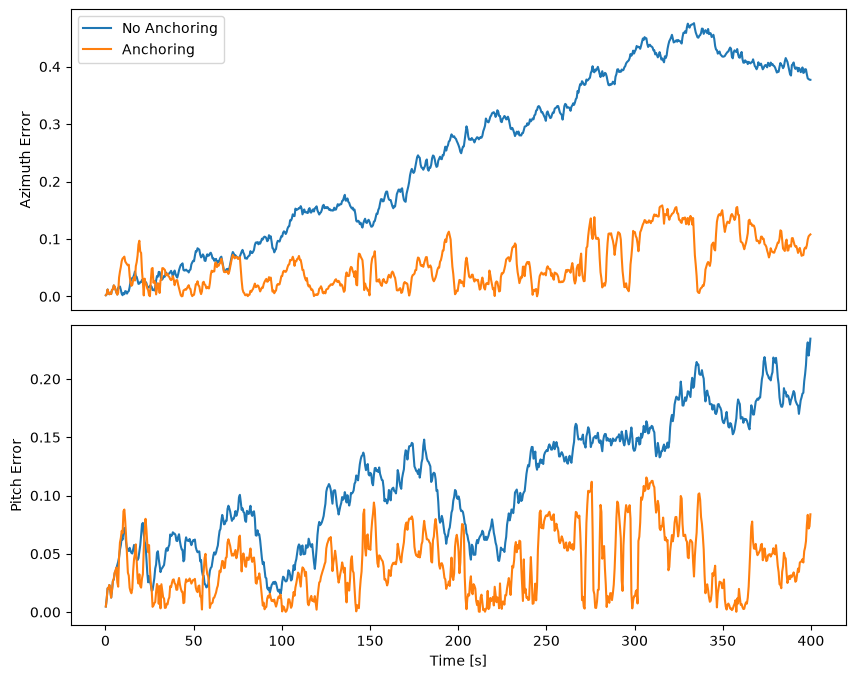

In [7]:

smooth_interval = 10
fig, ax = plt.subplots(
    nrows=2,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"hspace": (0.05)},
)
for angle_iter, angle in enumerate(["Azimuth", "Pitch"]):
    anchored_error = angular_error(
        recording_anchor["decoded_angle"][:, angle_iter],
        bat_flight["dir_torus"][::interval, angle_iter],
    )
    error = angular_error(
        recording["decoded_angle"][:, angle_iter],
        bat_flight["dir_torus"][::interval, angle_iter],
    )
    ax[1 * angle_iter].plot(
        smooth_ts(bat_flight["time"][::interval], smooth_interval),
        np.abs(smooth_ts(error, smooth_interval)),
        label="No Anchoring",
    )
    ax[1 * angle_iter].plot(
        smooth_ts(bat_flight["time"][::interval], smooth_interval),
        np.abs(smooth_ts(anchored_error, smooth_interval)),
        label="Anchoring",
    )
    ax[1 * angle_iter].set_ylabel(angle + " Error")

for axis_iter in range(len(ax) - 1):
    ax[axis_iter].get_xaxis().set_visible(False)


ax[0].legend()
ax[-1].set_xlabel("Time [s]")
fig.savefig(os.path.join(PLOTS_DIR, "bat_flight_anchoring_effect.png"))

Text(0.5, 1.0, 'Conjunctive')

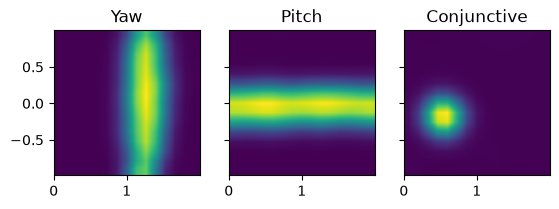

In [8]:
from grid_cells.plot_tools import activity_map

cell_index = 1
fig, ax = plt.subplots(ncols=3, sharey=True)
activity, counts, direction_edges = activity_map(
    bat_flight["dir_torus"][::interval], recording_anchor["yaw_cells"][:, 100], nbins=15, sigma=1
)
ax[0].imshow(
    activity.T,
    extent=(
        direction_edges[0][0] / np.pi,
        direction_edges[0][-1] / np.pi,
        direction_edges[1][0] / np.pi,
        direction_edges[1][-1] / np.pi,
    ),
    origin="lower",
    interpolation="bilinear",
)
ax[0].set_title("Yaw")
activity, counts, direction_edges = activity_map(
    bat_flight["dir_torus"][::interval],
    recording_anchor["pitch_cells"][:, cell_index],
    nbins=15,
    sigma=1,
)

ax[1].imshow(
    activity.T,
    extent=(
        direction_edges[0][0] / np.pi,
        direction_edges[0][-1] / np.pi,
        direction_edges[1][0] / np.pi,
        direction_edges[1][-1] / np.pi,
    ),
    origin="lower",
    interpolation="bilinear",
)
ax[1].set_title("Pitch")

activity, counts, direction_edges = activity_map(
    bat_flight["dir_torus"][::interval],
    recording_anchor["conj_cells"][:, cell_index],
    nbins=15,
    sigma=1,
)
ax[2].imshow(
    activity.T,
    extent=(
        direction_edges[0][0] / np.pi,
        direction_edges[0][-1] / np.pi,
        direction_edges[1][0] / np.pi,
        direction_edges[1][-1] / np.pi,
    ),
    origin="lower",
    interpolation="bilinear",
)
ax[2].set_title("Conjunctive")

In [9]:
recording_anchor["conj_cells"].max(), recording_anchor[
    "pitch_cells"
].max(), recording_anchor["yaw_cells"].max()

(np.float64(0.678000756056171),
 np.float64(0.880081154638904),
 np.float64(0.8809863212160214))

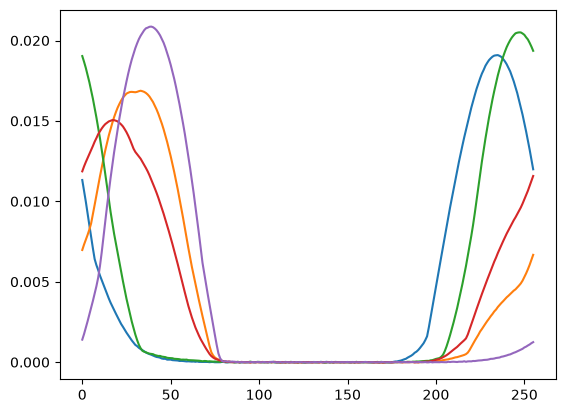

In [ ]:


plt.plot(recording_anchor["pitch_anchor_weights"][-1, ::-1, :])

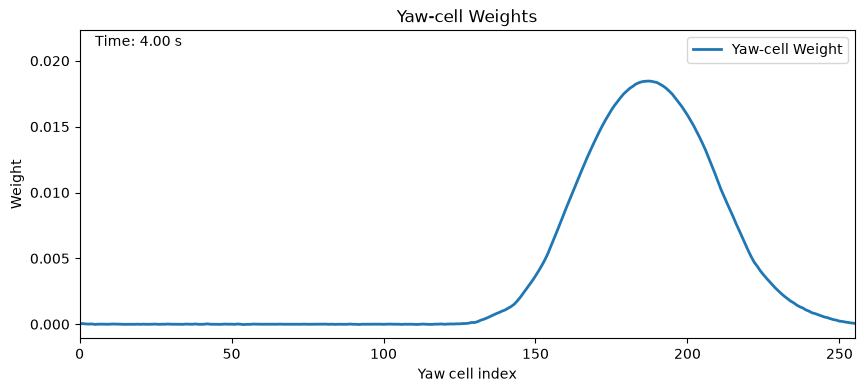

In [11]:
from matplotlib.animation import FuncAnimation, FFMpegWriter

plt.rcParams["animation.ffmpeg_path"] = "/opt/homebrew/bin/ffmpeg"
yaw_anchor_weight = recording_anchor["yaw_anchor_weights"][..., 0]
step = 10
frame_indices = np.arange(0, len(yaw_anchor_weight), step, dtype=int)

n_cells = yaw_anchor_weight.shape[1]
y_min, y_max = np.percentile(yaw_anchor_weight[::step], [1, 99])

margin = 0.05 * (y_max - y_min)

fig, ax = plt.subplots(figsize=(10, 4))
(line,) = ax.plot([], [], lw=2, label="Yaw-cell Weight")
time_text = ax.text(0.02, 0.95, "", transform=ax.transAxes)

ax.set_xlim(0, n_cells - 1)
ax.set_ylim(y_min - margin, y_max + margin)
ax.set_xlabel("Yaw cell index")
ax.set_ylabel("Weight")
ax.set_title("Yaw-cell Weights")
ax.legend()


def update(frame):
    index = frame_indices[frame]
    line.set_data(np.arange(n_cells), yaw_anchor_weight[index])

    time_text.set_text(f"Time: {bat_flight['time'][index]:.2f} s")
    return line, time_text


yaw_weight_animation = FuncAnimation(
    fig,
    update,
    frames=len(frame_indices),
    interval=40,
    blit=True,
)
FFwriter = FFMpegWriter(fps=25)
yaw_weight_animation.save(
    os.path.join(PLOTS_DIR, "bat_flight_yaw_weight_learning.mp4"), writer=FFwriter
)